**Unsupervised Learning
Finding Hidden Groups**

What is Unsupervised Learning?

In supervised learning you have a label (the answer) for every row of training data. In unsupervised learning there are
no labels — the algorithm must discover structure, patterns, and groups entirely on its own.

Supervised Learning vs Unsupervised Learning

| Feature                 | Supervised Learning                                                         | Unsupervised Learning                                                            |
| ----------------------- | --------------------------------------------------------------------------- | -------------------------------------------------------------------------------- |
| **Labels**              | Requires labeled data (target column available)                             | No labels required (no target column)                                            |
| **Goal**                | Learn from known answers and make predictions                               | Discover hidden patterns, groups, or relationships                               |
| **Input Data**          | Features + Target (X and y)                                                 | Features only (X)                                                                |
| **Output**              | Predicted class or numerical value                                          | Clusters, components, associations, anomalies                                    |
| **Common Algorithms**   | Logistic Regression, Linear Regression, Decision Tree, Random Forest   | K-Means, PCA, DBSCAN, Hierarchical Clustering, Autoencoders                      |
| **Evaluation Metrics**  | Accuracy, Precision, Recall, F1-Score, ROC-AUC, RMSE                        | Silhouette Score, Elbow Method, Cluster Visualization                            |
| **Teacher Present?**    |  Yes (correct answers available)                                           |  No (model learns on its own)                                                   |
| **Typical Questions**   | "Will this customer buy?" "Is this email spam?"                             | "Can customers be grouped?" "Are there hidden patterns?"                         |
| **Real-World Examples** | Spam Detection, Disease Prediction, House Price Prediction, Fraud Detection | Customer Segmentation, Market Basket Analysis, Topic Modeling, Anomaly Detection |


Few example where we can use non supervised learning.

Imagine you are given a large dataset, but there are no answers, labels, or target column provided.

For example:

A shopping website has data about 1 lakh customers.

A news website has 10,000 articles.

A bank has millions of transactions.

Nobody tells us:

Which customer belongs to which group.

Which articles belong to which topic.

Which transactions are fraudulent.

The goal is to let the machine discover hidden patterns automatically.

This is called Unsupervised Learning.

Supervised vs Unsupervised Side by Side

See the difference in how you set up each type of problem:

In [ ]:
# ■■ Supervised vs Unsupervised Comparison ■■
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.datasets import make_blobs


# Generate toy data: 300 points, 3 natural clusters
X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.2,
    random_state=42)



# X → feature matrix (coordinates)
# y_true → the TRUE labels (we'd have these in supervised learning)
# ■■ Supervised approach: pretend we have labels ■■
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


X_tr,X_te,y_tr,y_te = train_test_split(
    X, y_true, test_size=0.2, random_state=42)

clf = LogisticRegression().fit(X_tr, y_tr)

print(f'Supervised accuracy: {clf.score(X_te,y_te):.2%}') # Uses labels

Supervised accuracy: 100.00%


In [ ]:
# ■■ Unsupervised approach: NO labels used at all ■■
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

cluster_labels = kmeans.fit_predict(X) # No y passed — only X!

print('Cluster assignments (first 10):', cluster_labels[:10])
# [0, 2, 1, 0, 2, ...] — but 0,1,2 are just cluster IDs, not class names

Cluster assignments (first 10): [1 1 0 2 1 2 0 2 0 0]


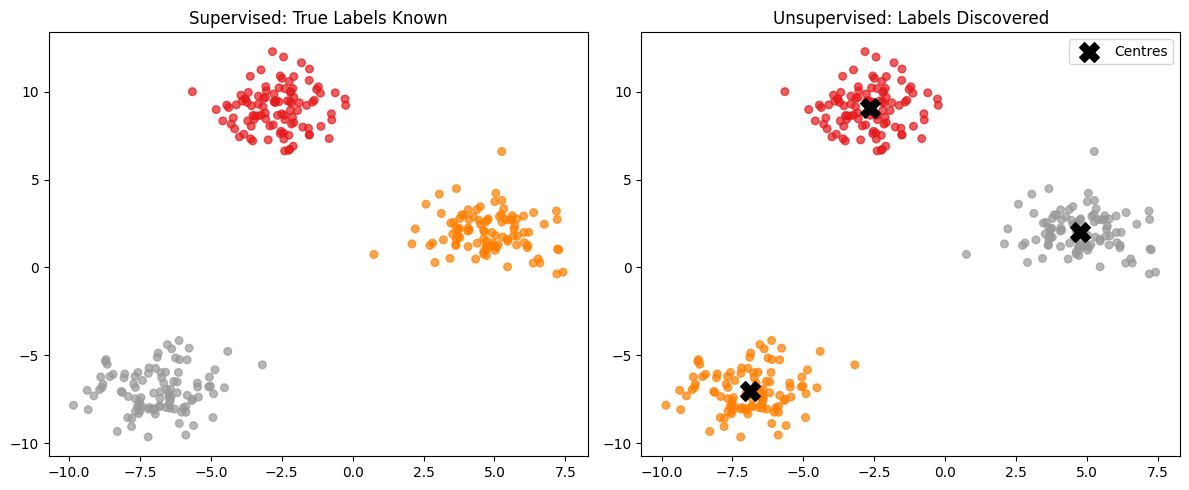

In [ ]:
# ■■ Plot both side by side ■■
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(X[:,0], X[:,1], c=y_true, cmap='Set1', s=30, alpha=0.7)
ax1.set_title('Supervised: True Labels Known', fontsize=12)
ax2.scatter(X[:,0], X[:,1], c=cluster_labels, cmap='Set1', s=30, alpha=0.7)
ax2.scatter(*kmeans.cluster_centers_.T, c='black', s=200, marker='X', label='Centres')
ax2.set_title('Unsupervised: Labels Discovered', fontsize=12)
ax2.legend(); plt.tight_layout(); plt.show()
# The colours may differ but the shapes should match!

In [ ]:
# ■■ K-Means: Manual + sklearn ■■
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
# ■■ Part 1: Manual K-Means ■■
def manual_kmeans(X, k=3, max_iter=10, seed=42):
  rng = np.random.default_rng(seed)
# Step 1: random initial centres
  centres = X[rng.choice(len(X), k, replace=False)]
  print(centres)
  for iteration in range(max_iter):
# Step 2: Assign each point to nearest centre
    dists = np.linalg.norm(X[:, np.newaxis] - centres, axis=2) # (n, k)
    labels = np.argmin(dists, axis=1) # (n,)
# Step 3: Move centres to mean of their cluster
    new_centres = np.array([X[labels == k_].mean(axis=0) for k_ in range(k)])
    print(f'Iter {iteration+1}: centre moved by {np.linalg.norm(new_centres-centres):.4f}')
    if np.allclose(centres, new_centres): print(' → Converged!'); break
    centres = new_centres
  return labels, centres
X, _ = make_blobs(n_samples=200, centers=3, random_state=42)
labels, centres = manual_kmeans(X, k=3)

[[ 5.5938806   2.62456094]
 [-7.70184759 -6.63642238]
 [ 3.86705362  1.73635108]]
Iter 1: centre moved by 6.2785
Iter 2: centre moved by 3.6678
Iter 3: centre moved by 0.0000
 → Converged!


In [ ]:
# ■■ Part 2: sklearn KMeans (the production version) ■■
scaler = StandardScaler() # Standardise BEFORE clustering
X_scaled = scaler.fit_transform(X) # K-Means uses distances → scale matters!
km = KMeans(
n_clusters=3, # K — number of clusters
init='k-means++', # Smart initialisation (better than random)
n_init=10, # Run 10 times with different starts, keep best
max_iter=300, # Max iterations per run
random_state=42
)
km.fit(X_scaled)
print(f'Inertia : {km.inertia_:.2f}') # Total within-cluster variance
print(f'Iterations : {km.n_iter_}') # How many loops it took
print(f'Cluster sizes: {np.bincount(km.labels_)}') # e.g. [67 66 67]

Inertia : 12.18
Iterations : 2
Cluster sizes: [67 66 67]


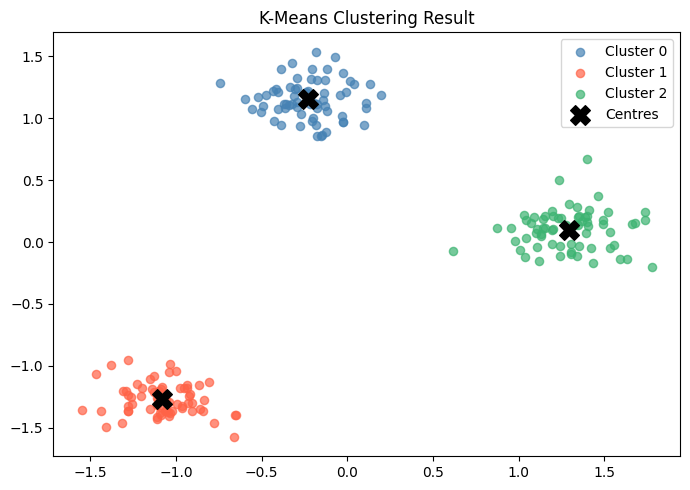

In [ ]:
# ■■ Visualise the result ■■
plt.figure(figsize=(7,5))
colours = ['steelblue','tomato','mediumseagreen']
for k in range(3):
  mask = km.labels_ == k
  plt.scatter(X_scaled[mask,0], X_scaled[mask,1],
    c=colours[k], s=35, alpha=0.7, label=f'Cluster {k}')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],
    c='black', s=200, marker='X', zorder=5, label='Centres')
plt.title('K-Means Clustering Result'); plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# ■■ Elbow Method + Silhouette Score ■■
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt, numpy as np


#used to create artifical data
X,_= make_blobs(
    n_samples=400,
    centers=4,
    cluster_std=1.5,
    random_state=42)

#transforming large data to [-1,1]
X = StandardScaler().fit_transform(X)

inertias, silhouettes, k_range = [], [], range(2, 11)
for k in k_range:
  km = KMeans(n_clusters=k, n_init=10, random_state=42)
  print(k)
  km.fit(X)
  inertias.append(km.inertia_)
  sil = silhouette_score(X, km.labels_) # -1 to +1, higher = better
silhouettes.append(sil)
print(f'K={k:2d} Inertia={km.inertia_:8.2f} Silhouette={sil:.4f}')

2
3
4
5
6
7
8
9
10
K=10 Inertia=   24.51 Silhouette=0.3534


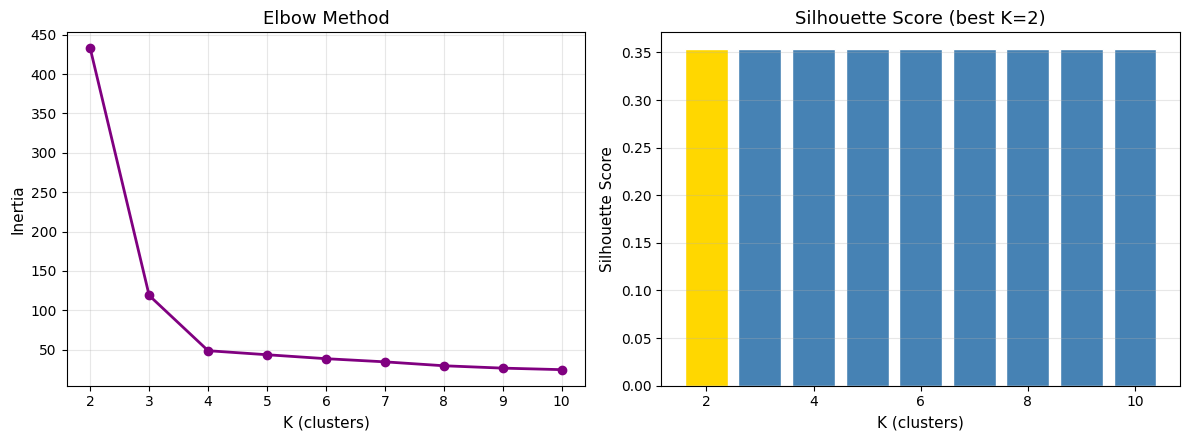


Elbow suggests: look around K=3-5
Silhouette says: best K = 2 (score=0.3534)


In [ ]:
# ■■ Plot both ■■
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
# Elbow plot
ax1.plot(k_range, inertias, 'o-', color='purple', lw=2)
ax1.set_xlabel('K (clusters)', fontsize=11); ax1.set_ylabel('Inertia', fontsize=11)
ax1.set_title('Elbow Method', fontsize=13); ax1.grid(alpha=0.3)
# Silhouette plot
best_k = k_range[silhouettes.index(max(silhouettes))]
bars = ax2.bar(k_range, silhouettes, color=['gold' if k==best_k else 'steelblue'
for k in k_range], edgecolor='white')
ax2.set_xlabel('K (clusters)', fontsize=11); ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title(f'Silhouette Score (best K={best_k})', fontsize=13); ax2.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()
print(f'\nElbow suggests: look around K=3-5')
print(f'Silhouette says: best K = {best_k} (score={max(silhouettes):.4f})')

In [ ]:
# ■■ Cluster Visualisation Toolkit ■■
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
# Use mall customer dataset (from Lab 7) or simulate here
np.random.seed(42)
n=200

age = np.concatenate(
        [
        np.random.normal(25,5,60),
        np.random.normal(45,8,80),
        np.random.normal(60,6,60)]
    )

income = np.concatenate(
    [np.random.normal(30,8,60),
     np.random.normal(60,12,80),
     np.random.normal(50,10,60)])


spending= np.concatenate(
    [np.random.normal(70,10,60),
     np.random.normal(50,15,80),
     np.random.normal(30,8,60)])

df = pd.DataFrame(
    {'Age':age,
     'Annual_Income':income,
     'Spending_Score':spending
      })

X = StandardScaler().fit_transform(df)

km = KMeans(n_clusters=3, n_init=10, random_state=42)
df['Cluster'] = km.fit_predict(X)
colors = ['#3B82F6','#EF4444','#10B981']
cluster_names = {0:'Young Spenders', 1:'Mid-Income Balanced', 2:'Older Conservative'}

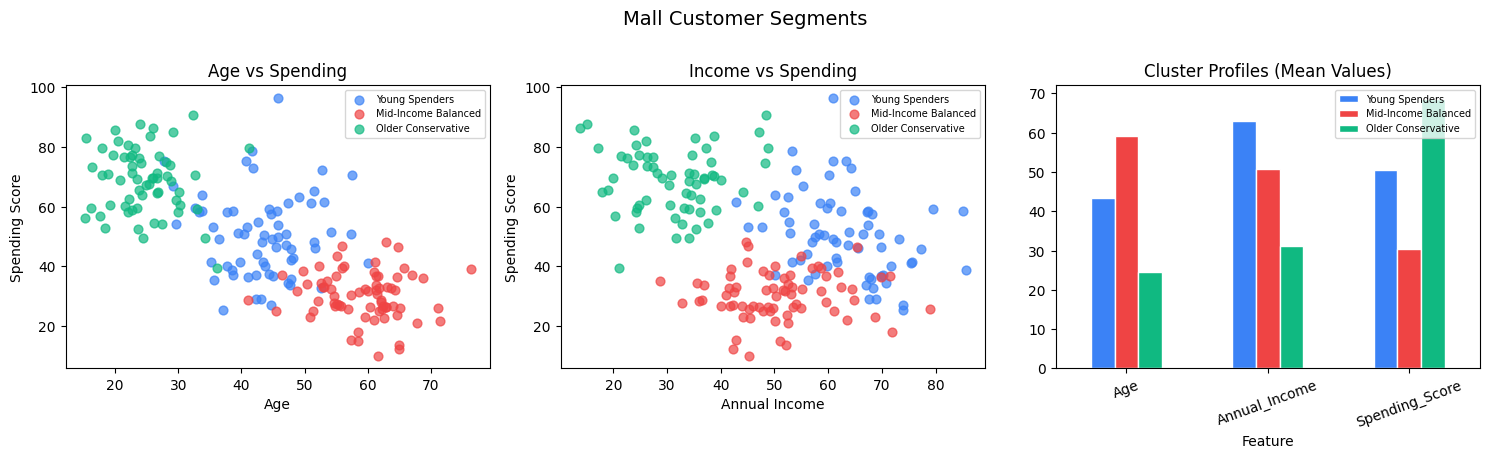

In [ ]:
# ■■ Plot 1: Scatter — Age vs Spending ■■
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for c in range(3):
  mask = df['Cluster'] == c
  axes[0].scatter(df[mask]['Age'], df[mask]['Spending_Score'],
    c=colors[c], s=40, alpha=0.7, label=cluster_names[c])
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Spending Score')
axes[0].set_title('Age vs Spending'); axes[0].legend(fontsize=7)
# ■■ Plot 2: Scatter — Income vs Spending ■■
for c in range(3):
  mask = df['Cluster'] == c
  axes[1].scatter(df[mask]['Annual_Income'], df[mask]['Spending_Score'],
  c=colors[c], s=40, alpha=0.7, label=cluster_names[c])
axes[1].set_xlabel('Annual Income'); axes[1].set_ylabel('Spending Score')
axes[1].set_title('Income vs Spending'); axes[1].legend(fontsize=7)
# ■■ Plot 3: Cluster profiles (mean values per cluster) ■■
profiles = df.groupby('Cluster')[['Age','Annual_Income','Spending_Score']].mean()
profiles.index = [cluster_names[i] for i in profiles.index]
profiles.T.plot(kind='bar', ax=axes[2], color=colors, edgecolor='white')
axes[2].set_title('Cluster Profiles (Mean Values)')
axes[2].set_xlabel('Feature'); axes[2].legend(fontsize=7)
axes[2].tick_params(axis='x', rotation=20)
plt.suptitle('Mall Customer Segments', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

In [ ]:
# ■■ Correlation Matrix + Heatmap ■■
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
# Load or create a dataset
# df = pd.read_csv('diabetes.csv') # Using the 'df' created in the previous cells

In [ ]:
# ■■ Correlation matrix (numbers) ■■
corr_matrix = df.corr(numeric_only=True) # Pearson by default
print('Correlation with Spending_Score:')
print(corr_matrix['Spending_Score'].sort_values(ascending=False).round(3))

Correlation with Spending_Score:
Spending_Score    1.000
Cluster           0.364
Annual_Income    -0.417
Age              -0.766
Name: Spending_Score, dtype: float64


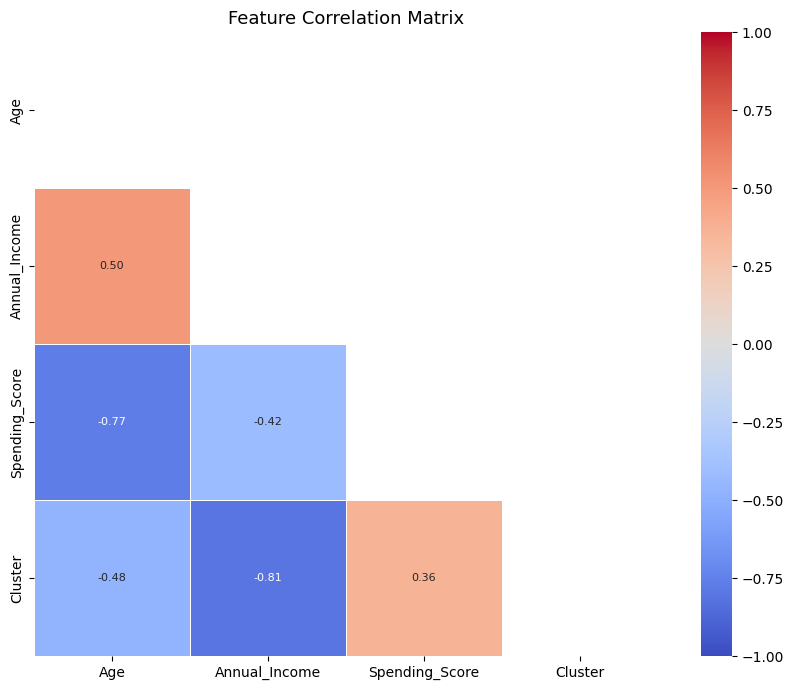

In [ ]:
# ■■ Seaborn heatmap ■■
plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # hide upper triangle
sns.heatmap(
corr_matrix,
annot=True, # show values in each cell
fmt='.2f', # 2 decimal places
cmap='coolwarm', # blue=positive, red=negative
mask=mask, # only show lower triangle
vmin=-1, vmax=1, # fix colour scale
             linewidths=0.5,
square=True,
annot_kws={'size': 8}
)
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
# ■■ Outlier Detection: Boxplots + IQR + Z-Score ■■
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
#df = pd.read_csv('diabetes.csv') # Using the 'df' created in the previous cells

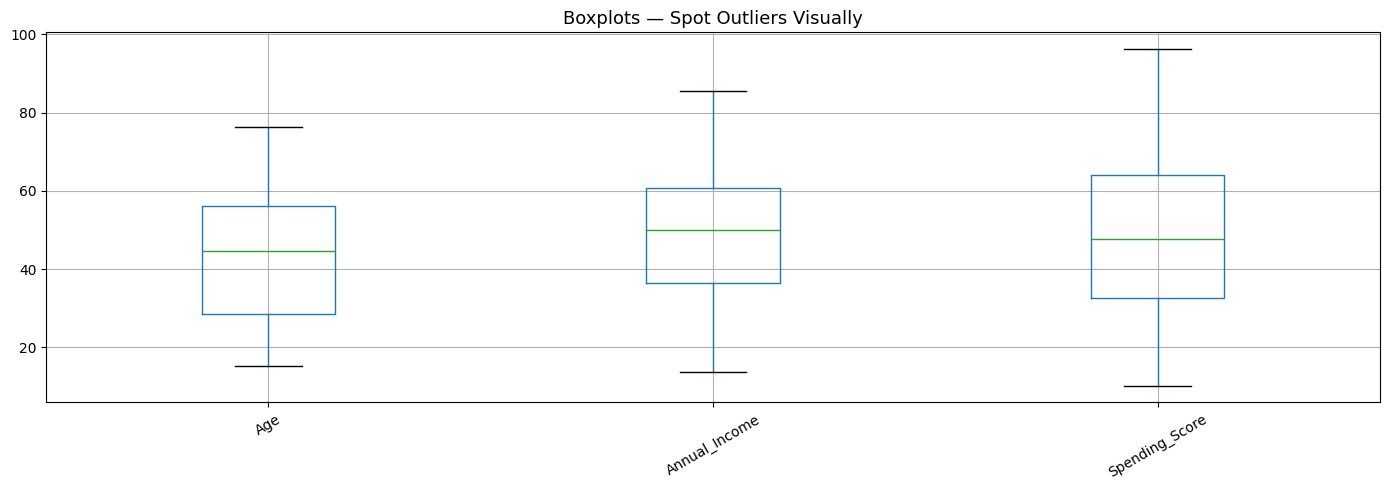

In [ ]:
# ■■ Part 1: Boxplots for all features ■■
plt.figure(figsize=(14, 5))
df.drop('Cluster', axis=1).boxplot()
plt.title('Boxplots — Spot Outliers Visually', fontsize=13)
plt.xticks(rotation=30); plt.tight_layout(); plt.show()
# The dots beyond the whiskers = outliers

In [ ]:
# ■■ Part 2: Quantify outliers with IQR method ■■
def find_outliers(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  outliers = df[(df[column] < lower) | (df[column] > upper)]
  return outliers, lower, upper
print(f'{'Column':25s} {'Outliers':>8} {'Lower':>8} {'Upper':>8}')
print('-' * 58)
for col in df.select_dtypes(include='number').columns:
  out, lo, hi = find_outliers(df, col)
  if len(out) > 0:
    print(f'{col:25s} {len(out):>8} {lo:>8.1f} {hi:>8.1f}')

Column                    Outliers    Lower    Upper
----------------------------------------------------------


In [ ]:
# ■■ Part 3: Handle outliers — three strategies ■■
col = 'Annual_Income' # Has many outliers
# Strategy A: Remove rows with outliers
_, lo, hi = find_outliers(df, col)
df_clean = df[(df[col] >= lo) & (df[col] <= hi)]
print(f'\nRows before: {len(df)}, after removing outliers: {len(df_clean)}')


Rows before: 200, after removing outliers: 200


In [ ]:
# Strategy B: Cap/Clip to fence values (keeps all rows)
df_capped = df.copy()
df_capped[col] = df_capped[col].clip(lower=lo, upper=hi)
print(f'Max Insulin before: {df[col].max():.0f}, after capping: {df_capped[col].max():.0f}')

Max Insulin before: 86, after capping: 86


In [ ]:
# Strategy C: Z-score method (flag anything > 3 std deviations)
from scipy import stats
z_scores = np.abs(stats.zscore(df.select_dtypes(include='number')))
outlier_rows = (z_scores > 3).any(axis=1).sum()
print(f'Rows with any z-score > 3: {outlier_rows}')

Rows with any z-score > 3: 0


LAB

A mall owner wants to understand their customers. You have data on 200 customers: customer ID, gender, age,
annual income (k$), and spending score (1–100).

Goal: Find natural customer groups — without any pre-defined
labels — so the marketing team can target each group differently.



Step 1 — Load & Explore

   CustomerID  Gender  Age  Income  SpendingScore
0           1    Male   57      36             53
1           2  Female   35      44             68
2           3  Female   60      55             23
3           4  Female   61      60             54
4           5    Male   59      48             31
(200, 5)
CustomerID        int64
Gender           object
Age               int64
Income            int64
SpendingScore     int64
dtype: object
CustomerID       0
Gender           0
Age              0
Income           0
SpendingScore    0
dtype: int64
       CustomerID    Age  Income  SpendingScore
count       200.0  200.0   200.0          200.0
mean        100.5   43.3    45.7           48.8
std          57.9   15.5    16.1           19.4
min           1.0   17.0    11.0           -2.0
25%          50.8   28.0    32.8           32.0
50%         100.5   45.0    46.5           50.0
75%         150.2   58.0    58.0           64.0
max         200.0   72.0    87.0           93.0


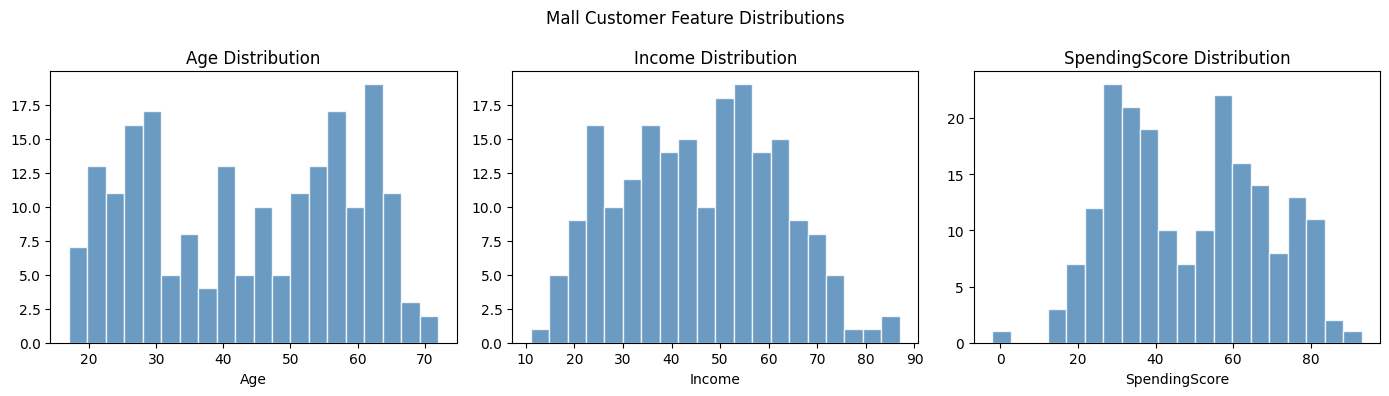

In [ ]:
# ■■ Load & Explore ■■
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
# Dataset: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial
# df = pd.read_csv('Mall_Customers.csv') # Original line causing FileNotFoundError

# Generate synthetic data similar to Mall_Customers.csv
np.random.seed(42)
n_samples = 200

customer_ids = np.arange(1, n_samples + 1)
gender = np.random.choice(['Male', 'Female'], size=n_samples, p=[0.4, 0.6]) # Roughly 40/60 split

# Age distribution (e.g., young, middle, older groups)
age_dist_young = np.random.normal(25, 5, n_samples // 3)
age_dist_mid = np.random.normal(45, 8, n_samples // 3)
age_dist_old = np.random.normal(60, 6, n_samples - 2 * (n_samples // 3))
age = np.concatenate([age_dist_young, age_dist_mid, age_dist_old])
np.random.shuffle(age) # Shuffle to mix age groups
age = age[:n_samples].astype(int) # Ensure exact n_samples and integer ages

# Annual Income distribution
income_dist_low = np.random.normal(30, 8, n_samples // 3)
income_dist_mid1 = np.random.normal(60, 12, n_samples // 3)
income_dist_mid2 = np.random.normal(50, 10, n_samples - 2 * (n_samples // 3))
income = np.concatenate([income_dist_low, income_dist_mid1, income_dist_mid2])
np.random.shuffle(income)
income = income[:n_samples].astype(int)

# Spending Score distribution
spending_dist_high = np.random.normal(70, 10, n_samples // 3)
spending_dist_mid = np.random.normal(50, 15, n_samples // 3)
spending_dist_low = np.random.normal(30, 8, n_samples - 2 * (n_samples // 3))
spending_score = np.concatenate([spending_dist_high, spending_dist_mid, spending_dist_low])
np.random.shuffle(spending_score)
spending_score = spending_score[:n_samples].astype(int)

# Create DataFrame with names matching the original CSV's post-rename columns
df = pd.DataFrame({
    'CustomerID': customer_ids,
    'Gender': gender,
    'Age': age,
    'Income': income,
    'SpendingScore': spending_score
})

print(df.head())
print(df.shape) # (200, 5)
print(df.dtypes) # int64 and object columns
print(df.isnull().sum()) # Check: should be 0 missing values
print(df.describe().round(1)) # Stats overview
# The original line `df.columns = ['CustomerID','Gender','Age','Income','SpendingScore']` is now redundant
# as the DataFrame is created with these column names directly.

# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Age','Income','SpendingScore']):
  ax.hist(df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
  ax.set_title(f'{col} Distribution'); ax.set_xlabel(col)
plt.suptitle('Mall Customer Feature Distributions'); plt.tight_layout(); plt.show()

Step 2 — Elbow Method: Find the Best K

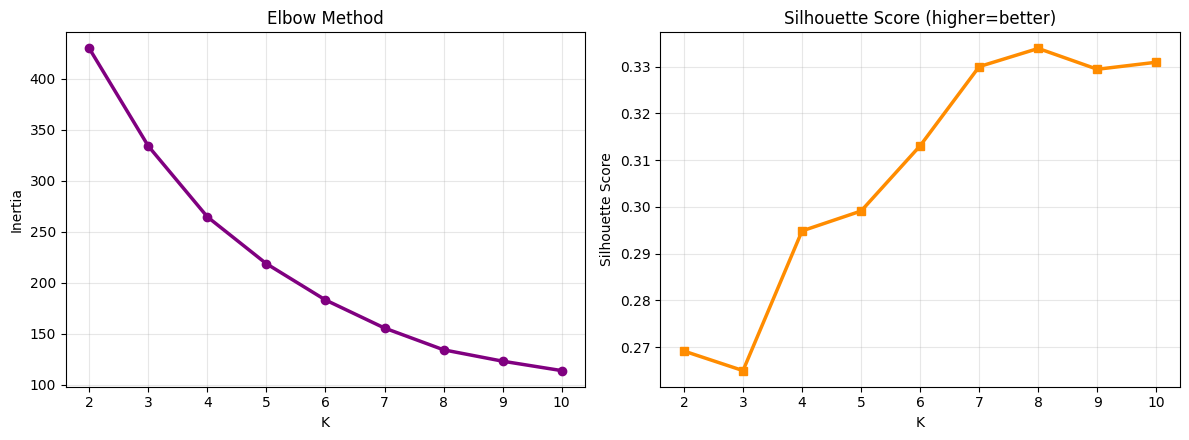

In [ ]:
# ■■ Elbow + Silhouette ■■
# Select features for clustering (drop ID and Gender for now)
features = ['Age', 'Income', 'SpendingScore']
X = df[features]
# Standardise: K-Means uses Euclidean distance — scale matters!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
inertias, sil_scores = [], []
K_range = range(2, 11)
for k in K_range:
  km = KMeans(n_clusters=k, n_init=10, random_state=42)
  km.fit(X_scaled)
  inertias.append(km.inertia_)
  sil_scores.append(silhouette_score(X_scaled, km.labels_))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(K_range, inertias, 'o-', color='purple', lw=2.5)
ax1.set_xlabel('K'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method'); ax1.grid(alpha=0.3)
ax2.plot(K_range, sil_scores, 's-', color='darkorange', lw=2.5)
ax2.set_xlabel('K'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score (higher=better)'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Step 3 — Fit K-Means and Profile the Clusters

          Age             Income             SpendingScore            
         mean   std count   mean   std count          mean   std count
Cluster                                                               
0        56.0   6.6    32   56.8   8.6    32          66.2  10.4    32
1        26.3   5.8    39   51.1  14.2    39          66.7  11.5    39
2        28.9   7.2    44   33.4  11.5    44          38.7  11.4    44
3        53.2  11.3    44   59.8   8.5    44          29.2   9.1    44
4        54.4   8.3    41   29.8   7.2    41          49.9  18.4    41


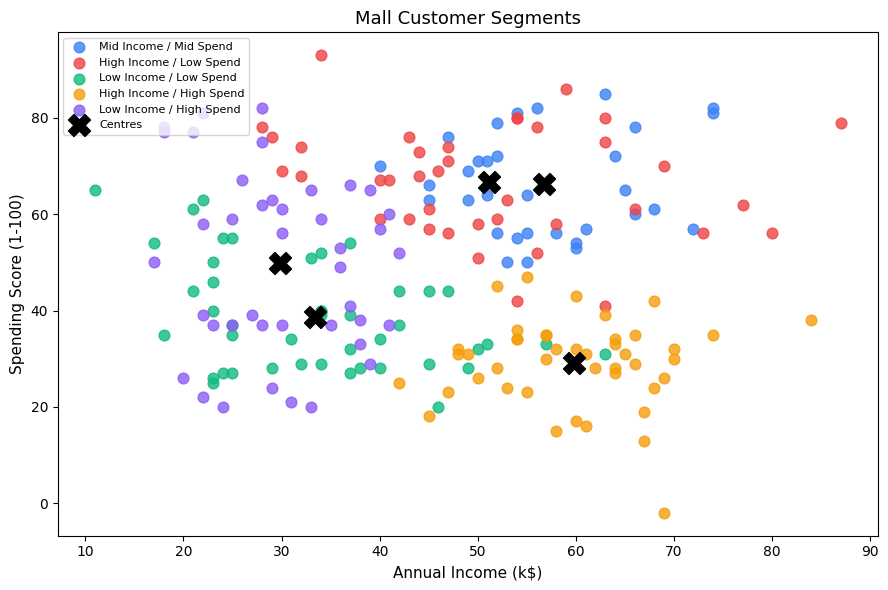

In [ ]:
# ■■ Fit K-Means + Profile Clusters ■■
best_k = 5 # Typical result for this dataset
km = KMeans(n_clusters=best_k, n_init=20, random_state=42)
df['Cluster'] = km.fit_predict(X_scaled)
# ■■ Cluster summary ■■
summary = df.groupby('Cluster')[features].agg(['mean','std','count'])
print(summary.round(1))
# ■■ Name the clusters based on their profiles ■■
cluster_labels = {
0: 'Mid Income / Mid Spend',
1: 'High Income / Low Spend',
2: 'Low Income / Low Spend',
3: 'High Income / High Spend',
4: 'Low Income / High Spend',
}
df['Segment'] = df['Cluster'].map(cluster_labels)
# ■■ Scatter plot: Income vs Spending, coloured by cluster ■■
palette = ['#3B82F6','#EF4444','#10B981','#F59E0B','#8B5CF6']
plt.figure(figsize=(9, 6))
for c in range(best_k):
  mask = df['Cluster'] == c
  plt.scatter(df[mask]['Income'], df[mask]['SpendingScore'],
    c=palette[c], s=60, alpha=0.8, label=cluster_labels[c])
centres_orig = scaler.inverse_transform(km.cluster_centers_)
plt.scatter(centres_orig[:,1], centres_orig[:,2], c='black',
s=250, marker='X', zorder=5, label='Centres')
plt.xlabel('Annual Income (k$)', fontsize=11)
plt.ylabel('Spending Score (1-100)', fontsize=11)
plt.title('Mall Customer Segments', fontsize=13)
plt.legend(loc='upper left', fontsize=8); plt.tight_layout(); plt.show()

Step 4 — Cluster Profiles & Marketing Recommendations

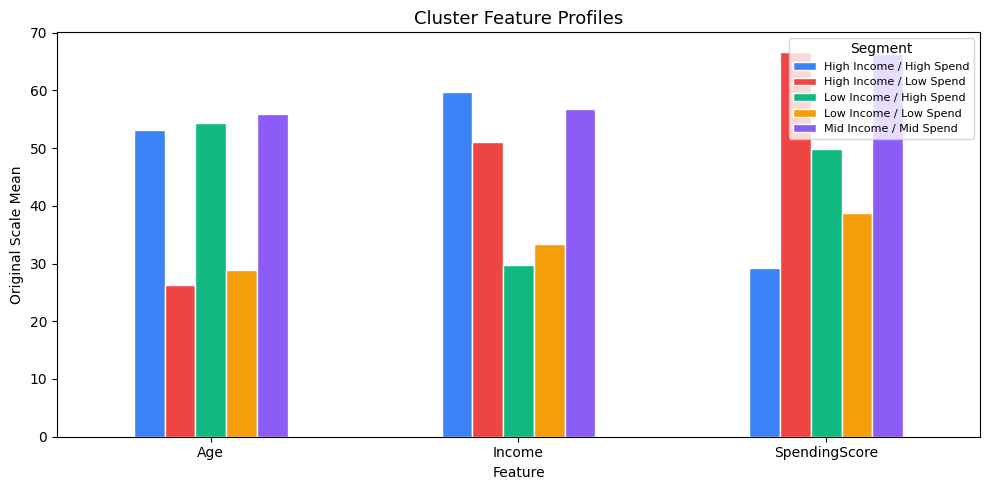


Marketing Strategy Recommendations:
High Income / High Spend: 44 customers
 → Loyalty programmes, premium brands, VIP events

High Income / Low Spend: 39 customers
 → Re-engagement campaigns, personalised offers

Low Income / High Spend: 41 customers
 → Flexible payment, budget promotions, discounts

Low Income / Low Spend: 44 customers
 → Value deals, essentials focus

Mid Income / Mid Spend: 32 customers
 → Broad marketing, seasonal promotions



In [ ]:
# ■■ Profiles + Marketing Insights ■■
# ■■ Radar / bar chart of cluster profiles ■■
profile_means = df.groupby('Segment')[features].mean()
profile_means.T.plot(kind='bar', figsize=(10, 5),
color=palette[:best_k], edgecolor='white')
plt.title('Cluster Feature Profiles', fontsize=13)
plt.xlabel('Feature'); plt.ylabel('Original Scale Mean')
plt.legend(title='Segment', fontsize=8, loc='upper right')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()
# ■■ Marketing strategy per segment ■■
strategies = {
'High Income / High Spend' : '→ Loyalty programmes, premium brands, VIP events',
'High Income / Low Spend' : '→ Re-engagement campaigns, personalised offers',
'Low Income / High Spend' : '→ Flexible payment, budget promotions, discounts',
'Low Income / Low Spend' : '→ Value deals, essentials focus',
'Mid Income / Mid Spend' : '→ Broad marketing, seasonal promotions',
}
print('\nMarketing Strategy Recommendations:')
print('=' * 60)
for seg, strat in strategies.items():
  count = len(df[df['Segment']==seg])
  print(f'{seg}: {count} customers')
  print(f' {strat}\n')